# 04. 조건부 Edge (Conditional Edge)

---

## 조건부 Edge란?

일반 Edge는 **항상 같은 다음 노드**로 이동한다다.  
조건부 Edge는 **State 값을 판단한 뒤 실행할 다음 노드를 동적으로 선택**한다.

```text
일반 Edge:     A  ───────────────────→  B

조건부 Edge:   A  → (라우팅 함수) → "B" → B
                                → "C" → C
                                → "D" → D
```

## 핵심 메서드

```python
builder.add_conditional_edges(
    "노드이름",          # 이 노드 실행 후 라우팅 함수가 실행됨
    routing_function,   # State를 받아 다음 노드 이름(str)을 반환하는 함수
    path_map=None       # 선택 사항: 반환값과 실제 노드 이름을 명시적으로 매핑함
)
```

라우팅 함수는 **문자열(str)** 또는 `END`를 반환한다.
반환값이 실제 노드 이름과 같으면 바로 연결할 수 있고, 더 명확한 그래프 시각화를 원하면 `path_map`을 함께 지정한다.

>초보자 실습에서는 path_map을 함께 사용하면 조건부 Edge가 어떤 노드로 갈 수 있는지 더 명확하게 확인할 수 있다.

## 환경변수 로딩

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

## 그래프 시각화 함수

In [2]:
from IPython.display import Image, display

def show_graph(app, title=""):
    if title:
        print(f"\n[{title}]")
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except:
        print(app.get_graph().draw_ascii())

## LangGraph 조건부 라우팅을 활용한 질문 분류 흐름


[조건부 라우팅 그래프]


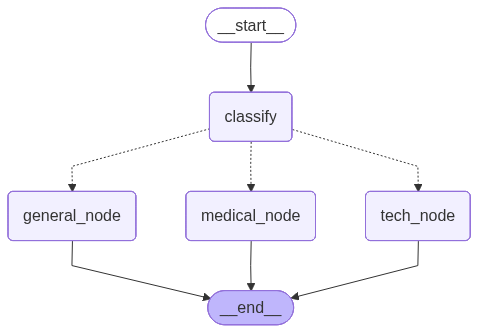

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# State 구조 정의
class RouterState(TypedDict):
    query: str
    category: str
    answer: str

# 라우팅 함수: State를 받아 다음 노드 이름을 반환
def route_query(state: RouterState) -> str:
    category = state.get("category", "general")
    if category == "tech":
        return "tech_node"
    elif category == "medical":
        return "medical_node"
    else:
        return "general_node"

def classify_node(state):
    query = state["query"].lower()
    if any(k in query for k in ["코드", "프로그래밍", "python"]):
        return {"category": "tech"}
    elif any(k in query for k in ["병원", "약", "질병"]):
        return {"category": "medical"}
    else:
        return {"category": "general"}

def tech_node(state):    return {
    "answer": f"[기술 답변] {state['query']}"
    }
def medical_node(state): return {
    "answer": f"[의료 답변] {state['query']}"
    }
def general_node(state): return {
    "answer": f"[일반 답변] {state['query']}"
    }

# 그래프 빌더 객체 생성
builder = StateGraph(RouterState)
# 노드 추가
builder.add_node("classify", classify_node)
builder.add_node("tech_node", tech_node)
builder.add_node("medical_node", medical_node)
builder.add_node("general_node", general_node)

# 엣지 추가
builder.add_edge(START, "classify")
# 조건부 엣지 추가: classify 노드의 출력에 따라 
# tech_node, medical_node, general_node로 라우팅
builder.add_conditional_edges(
    "classify",
    route_query,
    {
        "tech_node": "tech_node", 
        "medical_node": "medical_node", 
        "general_node": "general_node"
    }
)
# 조건부 분기 후 종료 지점으로 합류
builder.add_edge("tech_node", END)
builder.add_edge("medical_node", END)
builder.add_edge("general_node", END)
graph = builder.compile()
show_graph(graph, "조건부 라우팅 그래프")

In [4]:
## 그래프 실행 예시
initial_state = {"query": "Python으로 웹 개발을 하고 싶어요."}  
final_state = graph.invoke(initial_state)
print("\n최종 상태:", final_state)


최종 상태: {'query': 'Python으로 웹 개발을 하고 싶어요.', 'category': 'tech', 'answer': '[기술 답변] Python으로 웹 개발을 하고 싶어요.'}


In [5]:
result = graph.invoke({
    "query": "감기에 걸렸을 때 약을 어떻게 먹어야 하나요?",
    "category": "",
    "answer": ""
})

print("=== 의료 질문 실행 결과 ===")
for key, value in result.items():
    print(f"{key}: {value}")

=== 의료 질문 실행 결과 ===
query: 감기에 걸렸을 때 약을 어떻게 먹어야 하나요?
category: medical
answer: [의료 답변] 감기에 걸렸을 때 약을 어떻게 먹어야 하나요?


## 1. 점수 기반 등급 분류 (기본 조건부 Edge)

점수에 따라 A / B / C 등급 노드로 분기한다.

```text
START → 채점 → (점수 확인) → 우수반  → END
                            → 보통반  → END
                            → 기초반  → END
```
이 예제의 핵심은 `route_by_score()` 함수이다.  
이 함수는 현재 `State`의 score값을 읽고 다음에 실해할 노드 이름을 반환한다.


[점수 기반 분기 그래프]


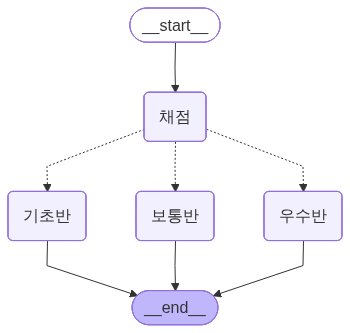

In [6]:

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# State 구조 정의
class GradeState(TypedDict):
    score: int      # 입력 값
    grade: str      # 출력 값
    message: str    # 출력 값 (학생에게 보여줄 메시지)

# --- 노드 정의 ----------------------------
def score_node(state: GradeState) -> dict:
    """
    점수를 확인하는 노드이다.
    State를 읽기만 하고 값을 변경하지 않는다.
    따라서 빈 dict를 반환하여 State를 그대로 유지한다.
    """
    print(f"  [채점] 점수: {state['score']}점")
    return {}  # score는 그대로 유지

def grade_a(state: GradeState) -> dict:
    """
    90점 이상인 경우
    A등급을 배정하는 노드이다.
    """
    print("  [우수반] A등급 배정")
    return {"grade": "A", "message": "축하합니다! 우수반에 배정되었습니다."}

def grade_b(state: GradeState) -> dict:
    """
    70점 이상 90점 미만인 경우
    B등급을 배정하는 노드이다.
    """
    print("  [보통반] B등급 배정")
    return {"grade": "B", "message": "보통반에 배정되었습니다."}

def grade_c(state: GradeState) -> dict:
    """
    70점 미만인 경우
    C등급을 배정하는 노드이다.
    """
    print("  [기초반] C등급 배정")
    return {"grade": "C", "message": "기초반에 배정되었습니다. 파이팅!"}

# --- 라우팅 함수 ----------------------------
def route_by_score(state: GradeState) -> str:
    """
    State의 score 값을 기준으로 다음 실행 경로를 결정한다.
    반환 문자열은 아래 add_conditional_edges()의 path_map key와 일치해야 한다.
    """
    score = state["score"]
    if score >= 90:
        return "우수반"
    elif score >= 70:
        return "보통반"
    else:
        return "기초반"

# --- 그래프 구성 ----------------------------
b = StateGraph(GradeState)

# 노드 추가
b.add_node("채점",  score_node)
b.add_node("우수반", grade_a)
b.add_node("보통반", grade_b)
b.add_node("기초반", grade_c)

# State에서 채점 노드 추가
b.add_edge(START, "채점")

# 조건부 Edge 추가: 채점 노드에서 route_by_score 함수의 반환값에 따라 분기
b.add_conditional_edges(
    "채점", 
    route_by_score,
    {  # path_map: 반환값에 따른 다음 노드 매핑, 반환값과 노드명이 같은 경우는 생략 가능
        "우수반": "우수반",
        "보통반": "보통반",
        "기초반": "기초반"
    },
)  # 조건부 Edge

# 각 등급 노드에서 END로 연결
b.add_edge("우수반", END)
b.add_edge("보통반", END)
b.add_edge("기초반", END)

# 그래프를 실행 가능한 Runnable 형태로 컴파일한다.
app = b.compile()

# 그래프를 시각화한다.
show_graph(app, "점수 기반 분기 그래프")

### 다양한 점수로 테스트

In [7]:
# 다양한 점수로 테스트
for score in [95, 75, 55]:
    print(f"\n=== 점수: {score} ===")
    result = app.invoke({"score": score, "grade": "", "message": ""})
    print(f"  결과: {result['grade']}등급 → {result['message']}")


=== 점수: 95 ===
  [채점] 점수: 95점
  [우수반] A등급 배정
  결과: A등급 → 축하합니다! 우수반에 배정되었습니다.

=== 점수: 75 ===
  [채점] 점수: 75점
  [보통반] B등급 배정
  결과: B등급 → 보통반에 배정되었습니다.

=== 점수: 55 ===
  [채점] 점수: 55점
  [기초반] C등급 배정
  결과: C등급 → 기초반에 배정되었습니다. 파이팅!


---

## 2. 루프(Loop) 패턴 - 조건 충족까지 반복

LangGraph는 **사이클(순환)** 을 지원한다.  
조건이 충족되면 `END`로, 아니면 다시 처리 노드로 돌아간다.

```text
START → 처리 → (충분한가?) → YES → END
          ↑                  NO   |
          └───────────────────────┘
```

**활용 예**: 품질 검사, 재시도 로직, 반복 정제

루프를 만들 때는 반드시 종료 조건을 설계해야 한다.  
종료 조건이 없으면 그래프가 무한히 반복될 수 있다.

- 반복 횟수 확인


[카운트 루프 그래프]


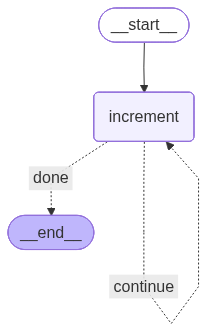

5


In [8]:
# ============================================================
# [State 정의] 루프에서 추적할 값 정의
# ============================================================
class CountState(TypedDict):
    count: int    # 현재 카운트 (반복마다 1씩 증가)
    target: int   # 목표 카운트 (종료 조건 기준값)

# ============================================================
# [노드 정의] 카운트를 1 증가시키는 처리 노드
# ============================================================
def increment_node(state):
    return {"count": state["count"] + 1}

# ============================================================
# [라우팅 함수] count가 target에 도달했는지 확인
# - "done"     반환 → END로 이동 (루프 탈출)
# - "continue" 반환 → increment 노드로 되돌아감 (루프 반복)
# ============================================================
def check_done(state) -> str:
    if state["count"] >= state["target"]:
        return "done"
    return "continue"

# ============================================================
# [그래프 구성] 루프 구조 조립
# START → increment → (check_done) → "done"     → END
#              ↑                      "continue" ↓
#              └──────────────────────────────────┘
# ============================================================
builder = StateGraph(CountState)
builder.add_node("increment", increment_node)
builder.add_edge(START, "increment")
builder.add_conditional_edges(
    "increment",
    check_done,
    {"done": END, "continue": "increment"}
)
graph = builder.compile()

# 그래프를 시각화한다.
show_graph(graph, "카운트 루프 그래프")

# ============================================================
# [실행] count=0에서 시작, target=5에 도달할 때까지 반복
# ============================================================
result = graph.invoke({"count": 0, "target": 5})
print(result["count"])  # 5


---
## 3. 최대 반복 횟수 제한 (안전 장치)

루프 그래프에는 **무한 루프 방지**를 위한 탈출 조건이 필요하다.


[안전한 루프 그래프]


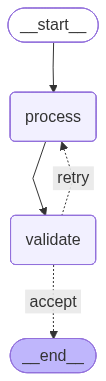

In [19]:
MAX_ITER = 5  # 최대 재시도 횟수 상수

class SafeLoopState(TypedDict):
    query: str
    answer: str
    is_valid: bool
    retry_count: int  # 반복 횟수 추적

def process_node(state):
    answer = f"답변 시도 #{state['retry_count'] + 1}"
    return {"answer": answer, "retry_count": state["retry_count"] + 1}

def validate_node(state):
    is_valid = len(state["answer"]) > 10
    return {"is_valid": is_valid}

def route_after_validate(state) -> str:
    if state["is_valid"]:
        return "accept"
    if state["retry_count"] >= MAX_ITER:
        return "give_up"   # 최대 횟수 초과 → 강제 종료
    return "retry"

builder = StateGraph(SafeLoopState)
builder.add_node("process", process_node)
builder.add_node("validate", validate_node)
builder.add_edge(START, "process")
builder.add_edge("process", "validate")
builder.add_conditional_edges(
    "validate",
    route_after_validate,
    {"accept": END, "give_up": END, "retry": "process"}
)
graph = builder.compile()
show_graph(graph, "안전한 루프 그래프")

In [20]:
print("\n=== 루프 실행 (초기값: 10) ===")
result = graph.invoke({"query": "테스트", "answer": "", "is_valid": False, "retry_count": 0})

print(f"\n최종값: {result['answer']},  반복횟수: {result['retry_count']}")


=== 루프 실행 (초기값: 10) ===

최종값: 답변 시도 #5,  반복횟수: 5


아래 예저는 두 가지 종료 조건을 둔다.
1. 품질 점수 `quality`가 80 이상이면 종료한다.
2. 최대 반복 회수 `MAX_ITER`에 도달하면 강제로 종료한다.

실제 LLM 기반 정제.검토 그래프에서도 이와 같은 안전 장치가 중요하다.


[품질 게이트 루프]


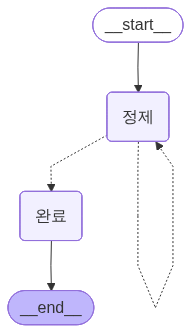

In [22]:
MAX_ITER = 5  # 최대 반복 횟수

class SafeLoopState(TypedDict):
    text: str
    quality: int   # 품질 점수 (0~100)
    attempts: int  # 현재까지의 정제 시도 횟수

def refine(state: SafeLoopState) -> dict:
    """
    텍스트를 정제하고 품질 점수를 높이는 노드다.
    실제 서비스에서는 LLM이 초안을 개선하고,
    여기서는 실습 이해를 위해 품질 점수가 30점씩 올라간다고 가정한다.
    """
    next_attempt = state["attempts"] + 1
    new_quality = min(state["quality"] + 30, 100)
    new_text    = state["text"] + f" [개선{state['attempts']+1}차]"
    print(f"  [정제 #{state['attempts']+1}] 품질: {state['quality']} → {new_quality}")
    return {
        "text": new_text, 
        "quality": new_quality, 
        "attempts": next_attempt,
    }

def quality_gate(state: SafeLoopState) -> str:
    """품질이 80 이상이면 완료, 그렇지 않으면 재정제한다. 단, 최대 시도 횟수를 초과하면 강제 종료한다."""
    if state["quality"] >= 80:
        print(f"  [판단] 품질 충족({state['quality']}>=80) → 완료")
        return "완료"
    
    if state["attempts"] >= MAX_ITER:
        print(f"  [판단] 최대 시도 횟수 초과 → 강제 종료")
        return "완료"
    
    print(f"  [판단] 품질 미달({state['quality']}<80) → 재정제")
    return "정제"

def done(state: SafeLoopState) -> dict:
    print(f"  [완료] 최종 품질={state['quality']}, 시도={state['attempts']}회")
    return {}

b = StateGraph(SafeLoopState)

# 정제 노드와 완료 노드를 추가한다.
b.add_node("정제", refine)
b.add_node("완료", done)

# START → 정제
b.add_edge(START,  "정제")

# 정제 후 품질 게이트를 통과하면 완료, 미달이면 다사 정제로 이동한다.
b.add_conditional_edges(
    "정제", 
    quality_gate,
    {
        "정제": "정제",  # 품질 미달 시 다시 정제 노드로
        "완료": "완료"   # 품질 충족 또는 최대 시도 초과 시 완료 노드로
    },
)

# 완료 노드는 END로 연결한다.
b.add_edge("완료", END)

app3 = b.compile()
show_graph(app3, "품질 게이트 루프")

In [23]:

print("\n=== 품질 정제 루프 실행 ===")
result = app3.invoke({"text": "초안", "quality": 10, "attempts": 0})
print(f"\n최종 텍스트: {result['text']}")


=== 품질 정제 루프 실행 ===
  [정제 #1] 품질: 10 → 40
  [판단] 품질 미달(40<80) → 재정제
  [정제 #2] 품질: 40 → 70
  [판단] 품질 미달(70<80) → 재정제
  [정제 #3] 품질: 70 → 100
  [판단] 품질 충족(100>=80) → 완료
  [완료] 최종 품질=100, 시도=3회

최종 텍스트: 초안 [개선1차] [개선2차] [개선3차]


---
## 4. 다단계 분기 (복합 조건)

실전에서는 여러 조건을 조합한 복합 분기를 사용한다.

다음 예제에서는 주문 금액과 주문 유형을 함께 판단한다.
1. 주문 금액이 1,000이면이면 주문을 거절한다.
2. 주문 유형이 `vip`이면 VIP 처리를 한다.
3. 주문 유형이 `urgent` 이면 긴급 처리를 한다.
4. 그 외에는 일반 처리를 한다.

조건의 우서가 중요하다.  
예를 들어 최소 주문금액 검사를 가장 먼저 해야 금액 미달 주문이 VIP/긴급 처리로 잘못 분기되지 않는다.


[주문 처리 분기 그래프]


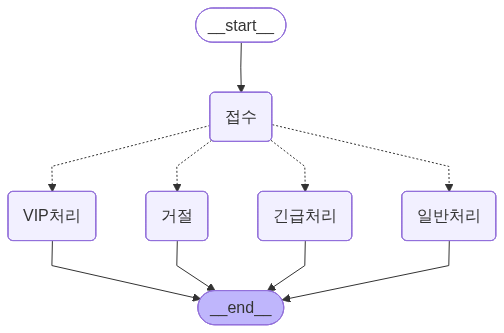

In [24]:
# 주문 처리 그래프에서 사용할 State 구조 정의
class OrderState(TypedDict):
    order_type: str     # "normal" | "urgent" | "vip"
    amount:     int     # 주문 금액
    result:     str     # 처리 결과 메시지

def receive_order(state: OrderState) -> dict:
    """
    주문 정보를 접수하는 노드입니다.
    값을 변경하지 않으므로 빈 dict를 반환한다.
    """
    print(f"  [접수] 주문유형={state['order_type']}, 금액={state['amount']:,}원")
    return {}

def process_normal(state: OrderState) -> dict:
    """일반 주문을 처리하는 노드이다."""
    print("  [일반처리] 3~5일 배송")
    return {"result": "일반 배송 처리 완료"}

def process_urgent(state: OrderState) -> dict:
    """긴급 주문을 처리하는 노드이다."""
    print("  [긴급처리] 당일 배송")
    return {"result": "긴급 배송 처리 완료"}

def process_vip(state: OrderState) -> dict:
    """VIP 주문을 처리하는 노드이다."""
    print("  [VIP처리] 전담 매니저 배정")
    return {"result": "VIP 전담 처리 완료"}

def reject_order(state: OrderState) -> dict:
    """최소 주문금액 미달 시 호출되는 노드이다."""
    print("  [거절] 최소 주문금액 미달")
    return {"result": "주문 거절 (최소 1,000원 이상)"}

def route_order(state: OrderState) -> str:
    """주문 금액과 주문 유형에 따라 처리 경로를 선택한다.
    조건은 위에서 아래 순서로 평가된다.
    1) 주문 금액이 1,000원 미만이면 "거절" 노드로 이동한다.
    2) 주문 유형이 "vip"이면 "VIP처리" 노드로 이동한다.
    3) 주문 유형이 "urgent"이면 "긴급처리" 노드로 이동한다.
    4) 그 외의 경우는 "일반처리" 노드로 이동한다.
    """
    if state["amount"] < 1000:
        return "거절"
    if state["order_type"] == "vip":
        return "VIP처리"
    elif state["order_type"] == "urgent":
        return "긴급처리"
    else:
        return "일반처리"

b = StateGraph(OrderState)

# 노드 추가
b.add_node("접수",   receive_order)
b.add_node("일반처리", process_normal)
b.add_node("긴급처리", process_urgent)
b.add_node("VIP처리",  process_vip)
b.add_node("거절",    reject_order)

# START → 접수
b.add_edge(START, "접수")

# 접수 후, route_order()의 반환값에 따라 다음 처리 노드로 분기한다.
b.add_conditional_edges(
    "접수", 
    route_order, 
    {
        "일반처리": "일반처리",
        "긴급처리": "긴급처리",
        "VIP처리": "VIP처리",
        "거절": "거절"
    },
)
for node in ["일반처리", "긴급처리", "VIP처리", "거절"]:
    b.add_edge(node, END)

app4 = b.compile()
show_graph(app4, "주문 처리 분기 그래프")

### 다양한 케이스 테스트

In [26]:
# 다양한 케이스 테스트
cases = [
    {"order_type": "normal", "amount": 15000, "result": ""},
    {"order_type": "urgent", "amount": 50000, "result": ""},
    {"order_type": "vip",    "amount": 200000, "result": ""},
    {"order_type": "normal", "amount": 500,    "result": ""},
]

for case in cases:
    print(f"\n=== {case['order_type'].upper()} / {case['amount']:,}원 ===")
    r = app4.invoke(case)
    print(f"  → {r['result']}")


=== NORMAL / 15,000원 ===
  [접수] 주문유형=normal, 금액=15,000원
  [일반처리] 3~5일 배송
  → 일반 배송 처리 완료

=== URGENT / 50,000원 ===
  [접수] 주문유형=urgent, 금액=50,000원
  [긴급처리] 당일 배송
  → 긴급 배송 처리 완료

=== VIP / 200,000원 ===
  [접수] 주문유형=vip, 금액=200,000원
  [VIP처리] 전담 매니저 배정
  → VIP 전담 처리 완료

=== NORMAL / 500원 ===
  [접수] 주문유형=normal, 금액=500원
  [거절] 최소 주문금액 미달
  → 주문 거절 (최소 1,000원 이상)


---

## 정리

```python
# 조건부 Edge 패턴

# 1. 라우팅 함수: State → 다음 경로 이름(str) 또는 END 반환
def route(state) -> str:
    if 조건A:
        return "경로A"
    if 조건B:
        return "경로B"
    return END  # 종료

# 2. 조건부 Edge 연결
builder.add_conditional_edges(
    "현재노드",
    route,
    {
        "경로A": "노드A",
        "경로B": "노드B",
        END: END,
    },
)

# 3. 루프 패턴
# 라우팅 함수에서 이전 노드나 현재 노드를 반환하면 반복 구조가 된다.
def should_continue(state) -> str:
    if 완료조건:
        return END
    return "처리노드"
```

| 패턴 | 라우팅 반환값 | 효과 |
|---|---|---|
| 단순 분기 | 다른 노드 이름 | 조건에 따라 경로 선택 |
| 루프 | 이전/현재 노드 이름 또는 `END` | 조건 충족까지 반복 |
| 조기 종료 | `END` | 중간에 바로 종료 |
| 안전 루프 | 다음 노드 이름 또는 완료 노드 | 반복 횟수 제한을 둔 재시도 |

## 실습 핵심

1. 조건부 Edge는 `add_conditional_edges()`로 만든다.
2. 라우팅 함수는 현재 `State`를 읽고 다음 경로를 반환한다.
3. 반환값은 실제 노드 이름과 일치하거나 `path_map`으로 매핑되어야 한다.
4. 루프를 만들 때는 종료 조건과 최대 반복 횟수를 반드시 고려한다.
5. `path_map`을 명시하면 그래프 구조를 더 명확하게 볼 수 있다.

→ 다음: **LLM 챗봇** (`05_llm_chatbot.ipynb`)
